# Project Bayes — Main Plots v2 with Hard-Case Deep Dives

This notebook leads with the **main scatter plot** (every (case, prompt) point for both Models Under Testing), then shows **10 very-hard cases in detail** (5 positive PSI + 5 negative PSI, ringed in the scatter), then the remaining headline tables (judge agreement, complexity tier, LOS bucket).

The 10 hard cases are candidates for narrowing to 5 for the meeting walkthrough. Each case shows: rubric, scores, rendered input, ground truth, both model responses, and per-judge per-criterion grading.


## Setup

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

EVAL_DIR = Path("eval_output_psi")
ARTIFACTS = Path("hard_cases_artifacts")

df = pd.read_csv(EVAL_DIR / "per_case_scores.csv")
crit = pd.read_csv(EVAL_DIR / "criteria_long.csv")
done = df[df["error"].isna()].copy()

case_meta = pd.read_csv("eval_cases_psi.csv")[
    ["ENCOUNTER_ID", "PSI_CODE", "PSI_TITLE", "LABEL", "PRIMARY_DX_CODE",
     "COMPLEXITY_TIER", "LOS_BUCKET", "LOS_DAYS", "AGE_INT", "GENDER"]
].rename(columns={"ENCOUNTER_ID": "encounter_id"})
done = done.merge(case_meta, on="encounter_id", how="left")

# Load the 10 hard-case artifacts
hard_artifacts = sorted(ARTIFACTS.glob("hard_case_*.json"))
hard_cases = [json.loads(p.read_text()) for p in hard_artifacts]
print(f"Loaded {len(hard_cases)} hard-case artifacts:")
for c in hard_cases:
    print(f"  Case {c['case_label']}: {c['encounter_id'][:8]} / {c['prompt_id']} / "
          f"{c['psi_code']} ({c['label']}) — score mean = {(c['opus_score_mean'] + c['gpt55_score_mean'])/2:.2f}")


Loaded 10 hard-case artifacts:
  Case hard_case_01_positive_C8: D6C0514E / C8 / PSI_11_POSTOP_RESP_FAILURE (positive) — score mean = 0.07
  Case hard_case_02_positive_P7: D6C0514E / P7 / PSI_11_POSTOP_RESP_FAILURE (positive) — score mean = 0.09
  Case hard_case_03_positive_C8: 93DFE79F / C8 / PSI_11_POSTOP_RESP_FAILURE (positive) — score mean = 0.18
  Case hard_case_04_positive_P7: 93DFE79F / P7 / PSI_11_POSTOP_RESP_FAILURE (positive) — score mean = 0.00
  Case hard_case_05_negative_C8: 26DEEBA7 / C8 / PSI_17_BIRTH_TRAUMA (negative) — score mean = 0.15
  Case hard_case_06_negative_P7: 26DEEBA7 / P7 / PSI_17_BIRTH_TRAUMA (negative) — score mean = 0.00
  Case hard_case_07_positive_S1: 3F10EE61 / S1 / PSI_05_RETAINED_ITEM (positive) — score mean = 0.00
  Case hard_case_08_negative_S5: AF2F9446 / S5 / PSI_14_WOUND_DEHISCENCE (negative) — score mean = 0.00
  Case hard_case_09_positive_S5: 0658A2DA / S5 / PSI_09_POSTOP_HEMORRHAGE (positive) — score mean = 0.00
  Case hard_case_10_negative_C1

## 1. Main scatter — Opus vs GPT-5.5 across all (case, prompt) points

Each dot is one (case, prompt) — color by prompt. Ringed numbered points are the 10 very-hard cases we drill into below. **Green ring = positive PSI case, orange ring = negative PSI case.** Red X marks the overall mean for both models (dotted lines = each model's mean).


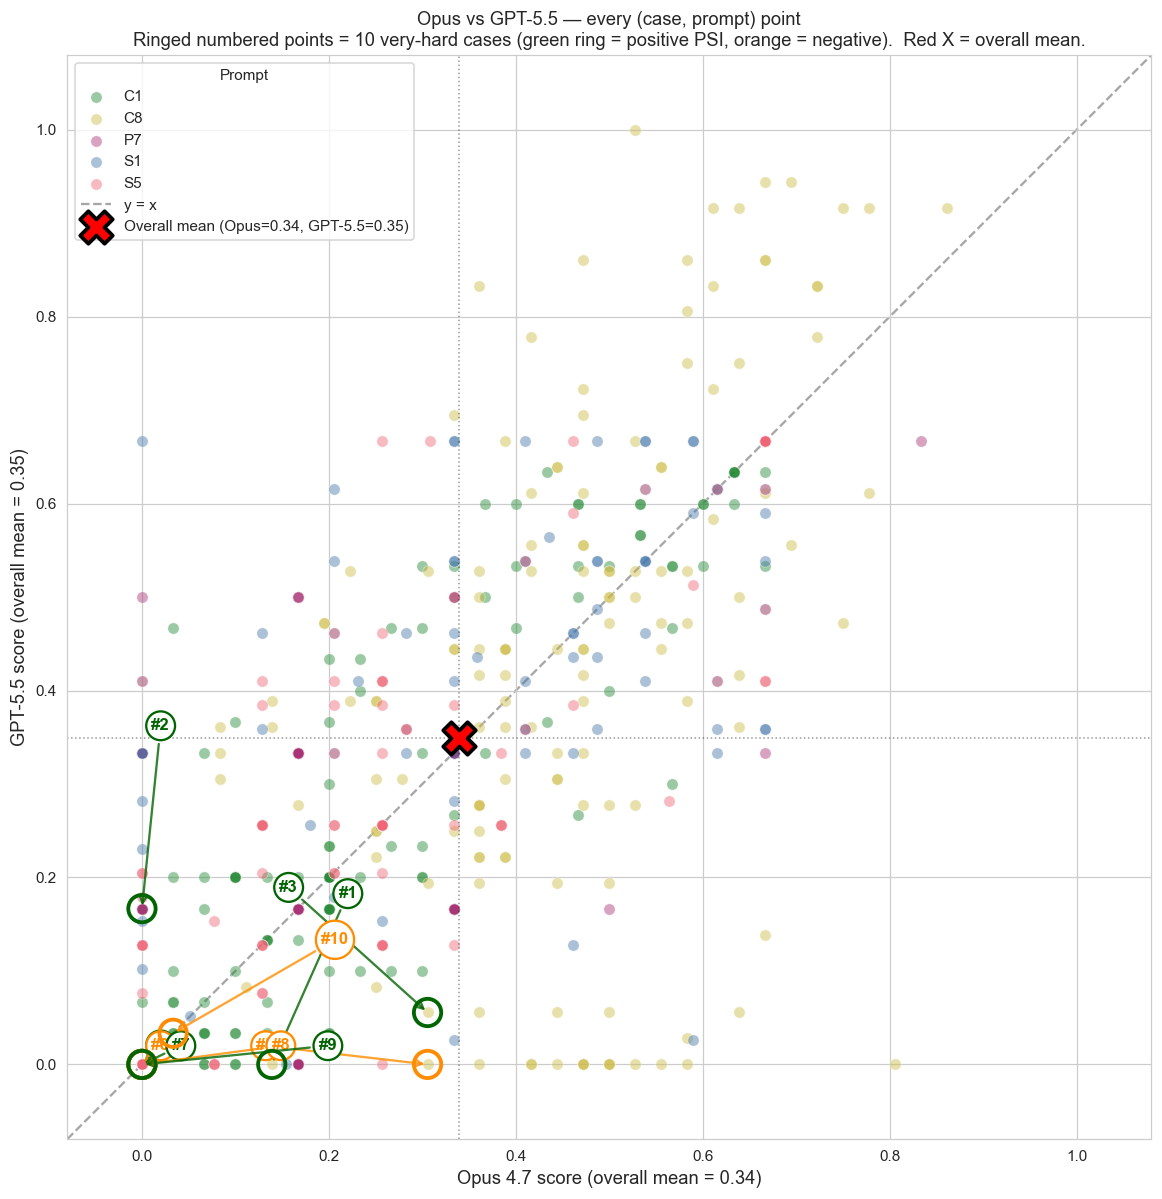

In [5]:
# Main scatter — Opus vs GPT-5.5 across all (case, prompt) points
# with arrows pointing to the 10 hand-picked very-hard cases

paired = done.pivot_table(
    index=["encounter_id", "prompt_id", "PSI_CODE", "LABEL"],
    columns="mut_model", values="score_mean"
).dropna().reset_index()

# Build the lookup for the 10 hard cases — get their (opus, gpt55) coords
hard_lookup = {(c["encounter_id"], c["prompt_id"]): c for c in hard_cases}
hard_coords = []
for c in hard_cases:
    enc, pid = c["encounter_id"], c["prompt_id"]
    row = paired[(paired["encounter_id"] == enc) & (paired["prompt_id"] == pid)]
    if len(row):
        opus = float(row.iloc[0]["claude-opus-4-7"])
        gpt  = float(row.iloc[0]["gpt-5.5"])
        hard_coords.append({"label": c["case_label"], "x": opus, "y": gpt,
                            "psi_label": c["label"]})

fig, ax = plt.subplots(figsize=(11, 11))
prompt_colors = {"S1": "#4477aa", "S5": "#ee6677", "C1": "#228833",
                 "C8": "#ccbb44", "P7": "#aa3377"}

for pid in sorted(paired["prompt_id"].unique()):
    sub = paired[paired["prompt_id"] == pid]
    ax.scatter(sub["claude-opus-4-7"], sub["gpt-5.5"],
               s=55, alpha=0.45, label=pid, color=prompt_colors.get(pid, "gray"),
               edgecolors="white", linewidth=0.5)

# y=x reference line
lims = [-0.08, 1.08]
ax.plot(lims, lims, "k--", alpha=0.35, label="y = x", zorder=0)

# Ring + arrow + number-label for each of the 10 hard cases
import numpy as np
np.random.seed(11)
for i, coord in enumerate(hard_coords, start=1):
    x, y = coord["x"], coord["y"]
    edge = "darkgreen" if coord["psi_label"] == "positive" else "darkorange"
    ax.scatter(x, y, s=320, facecolors="none", edgecolors=edge, linewidth=2.5, zorder=8)

    # Place label off to the side with an arrow
    # alternate label positions to avoid overlap
    angle_deg = 30 + (i * 36) % 360
    angle_rad = np.deg2rad(angle_deg)
    offset_x = 0.20 * np.cos(angle_rad)
    offset_y = 0.20 * np.sin(angle_rad)
    label_x = max(min(x + offset_x, 0.98), 0.02)
    label_y = max(min(y + offset_y, 0.98), 0.02)
    ax.annotate(f"#{i}",
                xy=(x, y),
                xytext=(label_x, label_y),
                fontsize=11, fontweight="bold",
                color=edge,
                ha="center", va="center",
                arrowprops=dict(arrowstyle="->", color=edge, lw=1.5, alpha=0.8),
                bbox=dict(boxstyle="circle,pad=0.3", fc="white", ec=edge, lw=1.5))

# Overall mean scores per MUT — plot a centroid marker showing where the "average" sits
opus_mean = done[done["mut_model"]=="claude-opus-4-7"]["score_mean"].mean()
gpt_mean  = done[done["mut_model"]=="gpt-5.5"]["score_mean"].mean()
# Compute per-(case, prompt) means as well — match the scatter's points
paired_means_x = paired["claude-opus-4-7"].mean()
paired_means_y = paired["gpt-5.5"].mean()

# Reference lines + centroid marker
ax.axvline(paired_means_x, color="black", linestyle=":", alpha=0.4, linewidth=1)
ax.axhline(paired_means_y, color="black", linestyle=":", alpha=0.4, linewidth=1)
ax.scatter([paired_means_x], [paired_means_y], s=450, marker="X",
           color="red", edgecolors="black", linewidth=2.5, zorder=10,
           label=f"Overall mean (Opus={paired_means_x:.2f}, GPT-5.5={paired_means_y:.2f})")

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(f"Opus 4.7 score (overall mean = {paired_means_x:.2f})", fontsize=12)
ax.set_ylabel(f"GPT-5.5 score (overall mean = {paired_means_y:.2f})", fontsize=12)
ax.set_title("Opus vs GPT-5.5 — every (case, prompt) point\n"
             "Ringed numbered points = 10 very-hard cases (green ring = positive PSI, orange = negative).  "
             "Red X = overall mean.",
             fontsize=12)
ax.legend(title="Prompt", loc="upper left", fontsize=10)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()




## 1b. Score vs complexity score, and Score vs length of stay

Two scatter plots, one per stratifying variable:
- **Left**: x-axis = `protege_score` (continuous complexity index), y-axis = `score_mean`
- **Right**: x-axis = `LOS_DAYS` (length of stay), y-axis = `score_mean`

Color-coded by Model Under Testing. Solid lines = linear fits.

**Interpretation**: a flat trend line means the benchmark scores don't depend on complexity or LOS — i.e., we're not just measuring "easy cases are easier." A non-flat trend would say complexity or LOS is a confound. Pearson correlations are printed below to quantify the flatness.


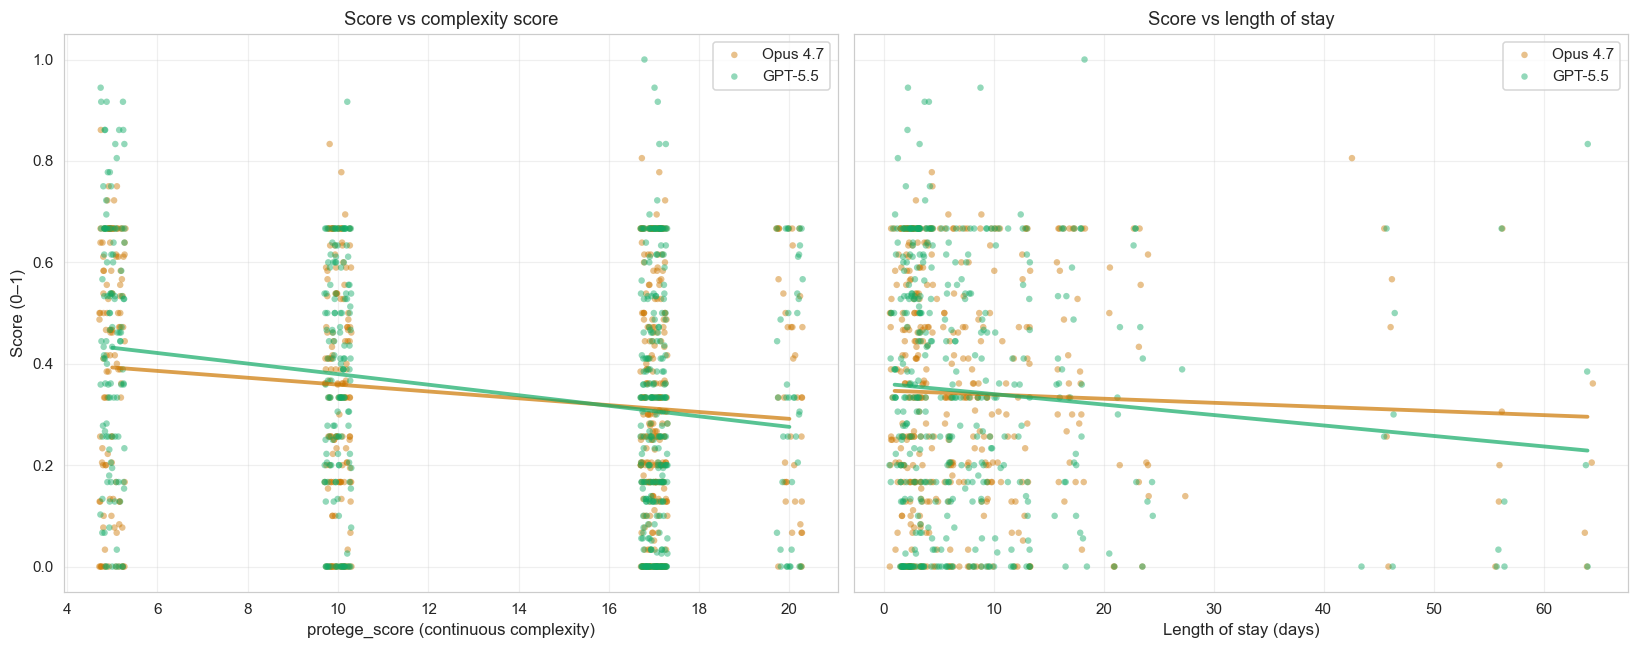

**Pearson correlations** (should be near zero for a well-calibrated benchmark):

,Model,score ↔ protege_score,score ↔ LOS_DAYS
0,Opus 4.7,-0.154,-0.038
1,GPT-5.5,-0.221,-0.088


In [3]:
# Score vs complexity score — scatter (one point per case-prompt-MUT row)
# Color-coded by MUT. Flat line = scores don't depend on complexity (good for benchmark calibration).

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# LEFT: Score vs protege_score (continuous complexity)
ax = axes[0]
for mut, color, label in [
    ("claude-opus-4-7", "#cc7700", "Opus 4.7"),
    ("gpt-5.5", "#11aa66", "GPT-5.5"),
]:
    sub = done[done["mut_model"] == mut]
    # Add small jitter on x so overlapping points are visible
    x_jit = sub["protege_score"] + np.random.uniform(-0.3, 0.3, size=len(sub))
    ax.scatter(x_jit, sub["score_mean"], s=18, alpha=0.45, color=color, label=label, edgecolors="none")
    # Linear fit line
    if len(sub) > 5:
        coef = np.polyfit(sub["protege_score"], sub["score_mean"], 1)
        xs = np.linspace(sub["protege_score"].min(), sub["protege_score"].max(), 50)
        ax.plot(xs, np.polyval(coef, xs), "-", color=color, linewidth=2.5, alpha=0.7)
ax.set_xlabel("protege_score (continuous complexity)", fontsize=11)
ax.set_ylabel("Score (0–1)", fontsize=11)
ax.set_title("Score vs complexity score")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# RIGHT: Score vs LOS_DAYS (length of stay)
ax = axes[1]
for mut, color, label in [
    ("claude-opus-4-7", "#cc7700", "Opus 4.7"),
    ("gpt-5.5", "#11aa66", "GPT-5.5"),
]:
    sub = done[done["mut_model"] == mut]
    sub = sub[sub["LOS_DAYS"].notna() & (sub["LOS_DAYS"] > 0)]  # filter zero-LOS rows
    x_jit = sub["LOS_DAYS"] + np.random.uniform(-0.5, 0.5, size=len(sub))
    ax.scatter(x_jit, sub["score_mean"], s=18, alpha=0.45, color=color, label=label, edgecolors="none")
    # Linear fit line
    if len(sub) > 5:
        coef = np.polyfit(sub["LOS_DAYS"], sub["score_mean"], 1)
        xs = np.linspace(sub["LOS_DAYS"].min(), sub["LOS_DAYS"].max(), 50)
        ax.plot(xs, np.polyval(coef, xs), "-", color=color, linewidth=2.5, alpha=0.7)
ax.set_xlabel("Length of stay (days)", fontsize=11)
ax.set_title("Score vs length of stay")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlations to quantify the flatness
display(Markdown("**Pearson correlations** (should be near zero for a well-calibrated benchmark):"))
import pandas as pd
corrs = []
for mut, label in [("claude-opus-4-7", "Opus 4.7"), ("gpt-5.5", "GPT-5.5")]:
    sub = done[done["mut_model"] == mut]
    sub_los = sub[sub["LOS_DAYS"].notna() & (sub["LOS_DAYS"] > 0)]
    r_complex = sub["score_mean"].corr(sub["protege_score"])
    r_los = sub_los["score_mean"].corr(sub_los["LOS_DAYS"])
    corrs.append({"Model": label, "score ↔ protege_score": round(r_complex, 3),
                  "score ↔ LOS_DAYS": round(r_los, 3)})
display(pd.DataFrame(corrs))


# 2. 10 very-hard cases 

## How these 10 were chosen

**Eligibility filter** (applied to all 1,139 clean (case, prompt, MUT) rows):

1. **Hard**: `max(opus_score, gpt55_score) ≤ 0.40` — both models partially or fully fail
2. **Valid ground truth**: GT excerpt is non-empty (≥ 20 chars) — failure isn't a data-quality artifact

**Two-part selection from that pool**:

### Part A — Three paired patients (6 cases)

We pick **3 specific encounters** that are hard on **both C8 AND P7**, then show each one twice (once per prompt). This lets us compare model behavior on the *same chart* across two different clinical tasks.

| # | Encounter | PSI | Label | Clinical scenario |
|---|---|---|---|---|
| Pair 1 | D6C0514E | PSI_11 RESP_FAILURE | positive | 24-day ESRD/MRSA, 922 labs (a very complex case) |
| Pair 2 | 93DFE79F | PSI_11 RESP_FAILURE | positive | 10-day cervical spinal fusion with epidural abscess |
| Pair 3 | 26DEEBA7 | PSI_17 BIRTH_TRAUMA | negative | 56-day NICU stay (HIE, neonatal seizures) |

These are the same 3 paired encounters we've been showing in the v2 notebook all along, kept for continuity. Cases #1/#3/#5 are the C8 (lab interpretation) version; #2/#4/#6 are the same patient on P7 (lab prediction).

### Part B — Four hard cases from S1, S5, C1 (4 cases)

So the notebook isn't dominated by C8 and P7, we add 4 cases from the extraction/summarization prompts. For each of S1, S5, C1, we picked the lowest-scoring case (by mean of both models) within the eligibility filter, while:

- Avoiding encounters already in the pairs (no duplicates)
- Balancing positive/negative PSI labels across the 4 picks
- Including S5 twice (one positive + one negative) since S5 has the most hard candidates

| # | Encounter | Prompt | PSI | Label | Why this one |
|---|---|---|---|---|---|
| 7 | 3F10EE61 | S1 | PSI_05 RETAINED_ITEM | positive | Lowest-scoring positive-PSI S1 case |
| 8 | AF2F9446 | S5 | PSI_14 WOUND_DEHISCENCE | negative | Lowest-scoring negative-PSI S5 case |
| 9 | 0658A2DA | S5 | PSI_09 HEMORRHAGE | positive | Lowest-scoring positive-PSI S5 case |
| 10 | 00413EB2 | C1 | PSI_06 PNEUMOTHORAX | negative | Lowest-scoring negative-PSI C1 case (balances overall pos/neg) |

### Final composition

- **All 5 prompts represented**: 3× C8, 3× P7, 1× S1, 2× S5, 1× C1
- **5 positive + 5 negative PSI labels** (balanced)
- **3 paired patient sets** for cross-prompt comparison
- **4 single cases** showing extraction/summarization failure modes

For each case below: metadata → prompt → rendered input → ground truth → both model responses → rubric → per-judge grading → **failure analysis** (case stats, score derivation, consensus failure modes with full judge rationales).


In [4]:
# Hard case #1 of 10
case = hard_cases[0]
display(Markdown(f"""# Case #1 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #1 — `D6C0514E` / **C8**

| Attribute | Value |
|---|---|
| PSI | **PSI_11_POSTOP_RESP_FAILURE** — Postoperative respiratory failure |
| Label | **positive** |
| Primary Dx | `S22.41XA` — CLOSED FRACTURE OF MULTIPLE RIBS OF RIGHT SIDE, INITIAL ENCOUNTER |
| Demographics | 69 y/o MALE |
| Complexity / LOS | hard / long (24d) |
| **Opus 4.7 score (3-judge mean)** | **0.14** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.42) |
| **GPT-5.5 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> Summarize the lab results below. Identify which values are abnormal and, for each abnormal result, describe what clinical action or follow-up order would be appropriate.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 874,389 chars*

...

#### GPT-5.5 — ❌ `C8.5` (+3 pts) — all 3 judges said **NO**

**Criterion question**: Does the response identify any critical/panic value if present in the labs?

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **no**

```
The model produced no response content
```


**`gpt-5.4-mini`** — answered **no**

```
The response provided is empty and does not identify any critical/panic lab value such as the markedly elevated troponin or lactate.
```


**`gemini-3.5-flash`** — answered **no**

```
The model response is completely empty and therefore does not identify any critical or panic values.
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



In [5]:
# Hard case #2 of 10
case = hard_cases[1]
display(Markdown(f"""# Case #2 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #2 — `D6C0514E` / **P7**

| Attribute | Value |
|---|---|
| PSI | **PSI_11_POSTOP_RESP_FAILURE** — Postoperative respiratory failure |
| Label | **positive** |
| Primary Dx | `S22.41XA` — CLOSED FRACTURE OF MULTIPLE RIBS OF RIGHT SIDE, INITIAL ENCOUNTER |
| Demographics | 69 y/o MALE |
| Complexity / LOS | hard / long (24d) |
| **Opus 4.7 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |
| **GPT-5.5 score (3-judge mean)** | **0.17** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.5) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> A lab panel has been ordered for this patient. Based on the clinical context (notes, prior labs, vitals, meds), predict the values of the next lab panel.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 3,007 chars*

...

#### GPT-5.5 — ⚠️ `P-C.3` (-1 pts) — all 3 judges said **YES**

**Criterion question**: Does the model predict lab values that hallucinate labs not actually drawn (e.g., predicts a lab that does not appear in the ground-truth panel)?

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **yes**

```
The model predicts numerous labs (WBC, hemoglobin, hematocrit, platelets, sodium, potassium, chloride, BUN, creatinine, glucose, calcium, magnesium, phosphorus, lactate, PT, INR, aPTT, troponin) that do not appear in the ground-truth panel, which only contains arterial blood gas and ventilator-related values.
```


**`gpt-5.4-mini`** — answered **yes**

```
The response predicts many labs not present in the ground-truth panel (e.g., WBC, hemoglobin, sodium, creatinine, lactate, INR, troponin), so it hallucinates labs that were not actually drawn.
```


**`gemini-3.5-flash`** — answered **yes**

```
The model predicted several labs, such as WBC, Hemoglobin, Platelets, and BMP components, which were not part of the actual ground-truth arterial blood gas panel drawn next.
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



In [6]:
# Hard case #3 of 10
case = hard_cases[2]
display(Markdown(f"""# Case #3 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #3 — `93DFE79F` / **C8**

| Attribute | Value |
|---|---|
| PSI | **PSI_11_POSTOP_RESP_FAILURE** — Postoperative respiratory failure |
| Label | **positive** |
| Primary Dx | `Z98.1` — S/P CERVICAL SPINAL FUSION |
| Demographics | 62 y/o MALE |
| Complexity / LOS | hard / long (10d) |
| **Opus 4.7 score (3-judge mean)** | **0.31** (Sonnet=0.33, GPT-mini=0.0, Gemini=0.58) |
| **GPT-5.5 score (3-judge mean)** | **0.06** (Sonnet=0.0, GPT-mini=0.17, Gemini=0.0) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> Summarize the lab results below. Identify which values are abnormal and, for each abnormal result, describe what clinical action or follow-up order would be appropriate.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 483,610 chars*

...

#### GPT-5.5 — ❌ `C8.5` (+3 pts) — all 3 judges said **NO**

**Criterion question**: Does the response identify any critical/panic value if present in the labs?

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **no**

```
The model response is empty and contains no content
```


**`gpt-5.4-mini`** — answered **no**

```
The response does not mention any critical or panic value, and none of the presented abnormal labs are explicitly identified as critical/panic in the response.
```


**`gemini-3.5-flash`** — answered **no**

```
The model response is completely empty and does not identify any critical or panic values.
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



In [7]:
# Hard case #4 of 10
case = hard_cases[3]
display(Markdown(f"""# Case #4 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #4 — `93DFE79F` / **P7**

| Attribute | Value |
|---|---|
| PSI | **PSI_11_POSTOP_RESP_FAILURE** — Postoperative respiratory failure |
| Label | **positive** |
| Primary Dx | `Z98.1` — S/P CERVICAL SPINAL FUSION |
| Demographics | 62 y/o MALE |
| Complexity / LOS | hard / long (10d) |
| **Opus 4.7 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |
| **GPT-5.5 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> A lab panel has been ordered for this patient. Based on the clinical context (notes, prior labs, vitals, meds), predict the values of the next lab panel.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 15,537 chars*

...

#### GPT-5.5 — ❌ `P-C.1` (+1 pts) — all 3 judges said **NO**

**Criterion question**: Does the model's predicted direction (high / low / normal) match the actual direction for the majority (>50%) of predicted labs?

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **no**

```
The model predicted a comprehensive metabolic/CBC panel
```


**`gpt-5.4-mini`** — answered **no**

```
The model predicted many blood chemistry and hematology labs, but the actual next panel shown is a urinalysis, so its high/low/normal direction does not match the majority of predicted labs.
```


**`gemini-3.5-flash`** — answered **no**

```
The model predicted a comprehensive blood panel (BMP, CBC, LFTs, inflammatory markers, coagulation), whereas the actual next lab panel ordered was a urinalysis, resulting in zero overlapping labs to evaluate for directional accuracy.
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



In [8]:
# Hard case #5 of 10
case = hard_cases[4]
display(Markdown(f"""# Case #5 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #5 — `26DEEBA7` / **C8**

| Attribute | Value |
|---|---|
| PSI | **PSI_17_BIRTH_TRAUMA** — Birth trauma - injury to neonate |
| Label | **negative** |
| Primary Dx | `R56.9` — SEIZURE (CMD) |
| Demographics | 0 y/o MALE |
| Complexity / LOS | hard / long (56d) |
| **Opus 4.7 score (3-judge mean)** | **0.31** (Sonnet=0.33, GPT-mini=0.0, Gemini=0.58) |
| **GPT-5.5 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> Summarize the lab results below. Identify which values are abnormal and, for each abnormal result, describe what clinical action or follow-up order would be appropriate.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 989,165 chars*

...

#### GPT-5.5 — ❌ `C8.5` (+3 pts) — all 3 judges said **NO**

**Criterion question**: Does the response identify any critical/panic value if present in the labs?

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **no**

```
The model produced no response content
```


**`gpt-5.4-mini`** — answered **no**

```
The response does not mention any critical or panic value, so it fails to identify one if present in the labs.
```


**`gemini-3.5-flash`** — answered **no**

```
The model response is completely empty and therefore does not identify any critical or panic values.
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



In [9]:
# Hard case #6 of 10
case = hard_cases[5]
display(Markdown(f"""# Case #6 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #6 — `26DEEBA7` / **P7**

| Attribute | Value |
|---|---|
| PSI | **PSI_17_BIRTH_TRAUMA** — Birth trauma - injury to neonate |
| Label | **negative** |
| Primary Dx | `R56.9` — SEIZURE (CMD) |
| Demographics | 0 y/o MALE |
| Complexity / LOS | hard / long (56d) |
| **Opus 4.7 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |
| **GPT-5.5 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> A lab panel has been ordered for this patient. Based on the clinical context (notes, prior labs, vitals, meds), predict the values of the next lab panel.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 22,034 chars*

...

#### GPT-5.5 — ❌ `P-C.1` (+1 pts) — all 3 judges said **NO**

**Criterion question**: Does the model's predicted direction (high / low / normal) match the actual direction for the majority (>50%) of predicted labs?

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **no**

```
The model predicted blood gas and basic metabolic panel values
```


**`gpt-5.4-mini`** — answered **no**

```
The response’s predicted directions are not aligned with the ground truth set of labs because it predicts many labs not in the actual panel and, among the overlapping concepts, it does not demonstrate a majority of correct high/low/normal directions.
```


**`gemini-3.5-flash`** — answered **no**

```
judge_error: GOOGLE_API_KEY (or GEMINI_API_KEY) not set in environment
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



In [10]:
# Hard case #7 of 10
case = hard_cases[6]
display(Markdown(f"""# Case #7 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #7 — `3F10EE61` / **S1**

| Attribute | Value |
|---|---|
| PSI | **PSI_05_RETAINED_ITEM** — Retained surgical item / unretrieved device fragment |
| Label | **positive** |
| Primary Dx | `T84.028A` — nan |
| Demographics | 78 y/o FEMALE |
| Complexity / LOS | hard / long (64d) |
| **Opus 4.7 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |
| **GPT-5.5 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> Extract the chief complaint (or reason for admission) from the clinical note(s) below. Return only the chief complaint text.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 9,619 chars*

...

#### GPT-5.5 — ❌ `S-A.4` (+3 pts) — all 3 judges said **NO**

**Criterion question**: Is every clinical claim in the model response traceable to the source material provided? A claim is 'traceable' if it appears in the source verbatim or as a clear paraphrase. If the response contains 

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **no**

```
The model response states &#x27;Left-sided weakness for stroke workup,&#x27; but while the note mentions LUE and LLE motor strength weakness (3-4/5), there is no mention of &#x27;stroke workup&#x27; anywhere in the source material, making this claim untraceable.
```


**`gpt-5.4-mini`** — answered **no**

```
The source mentions left-sided weakness, but it does not support the added claim that this was specifically for a stroke workup.
```


**`gemini-3.5-flash`** — answered **no**

```
judge_error: GOOGLE_API_KEY (or GEMINI_API_KEY) not set in environment
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



In [11]:
# Hard case #8 of 10
case = hard_cases[7]
display(Markdown(f"""# Case #8 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #8 — `AF2F9446` / **S5**

| Attribute | Value |
|---|---|
| PSI | **PSI_14_WOUND_DEHISCENCE** — Postoperative abdominal wound dehiscence (with reclosure) |
| Label | **negative** |
| Primary Dx | `T81.31XA` — WOUND DEHISCENCE, SURGICAL, INITIAL ENCOUNTER |
| Demographics | 68 y/o MALE |
| Complexity / LOS | medium / short (2d) |
| **Opus 4.7 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |
| **GPT-5.5 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> Extract the Assessment and Plan section from the clinical note below. Return the A&P text verbatim or as closely as possible.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 2,432 chars*

...

#### GPT-5.5 — ❌ `S-A.2` (+3 pts) — all 3 judges said **NO**

**Criterion question**: Does the model response contain at least 50% of the key facts from the ground-truth Assessment and Plan? Answer 'yes' if ≥ 50% of facts appear (both this and S-A.1 can be met if ≥ 80% applies).

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **no**

```
The model response contains completely different content (wound dehiscence, right knee debridement) unrelated to the ground truth A&amp;P facts about cardiac rehab metrics (DIST, Max HR, RPE, SPO2, lipids, family support, behavioral health consult), sharing zero key facts with the ground truth.
```


**`gpt-5.4-mini`** — answered **no**

```
The response does not reproduce the ground-truth Assessment/Plan content and instead contains unrelated pre-op/procedure text, so fewer than 50% of the key facts are present.
```


**`gemini-3.5-flash`** — answered **no**

```
judge_error: GOOGLE_API_KEY (or GEMINI_API_KEY) not set in environment
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



In [12]:
# Hard case #9 of 10
case = hard_cases[8]
display(Markdown(f"""# Case #9 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #9 — `0658A2DA` / **S5**

| Attribute | Value |
|---|---|
| PSI | **PSI_09_POSTOP_HEMORRHAGE** — Postoperative hemorrhage or hematoma (with treatment procedure) |
| Label | **positive** |
| Primary Dx | `R41.82` — ALTERED MENTAL STATUS, UNSPECIFIED ALTERED MENTAL STATUS TYPE |
| Demographics | 72 y/o FEMALE |
| Complexity / LOS | hard / long (8d) |
| **Opus 4.7 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |
| **GPT-5.5 score (3-judge mean)** | **0.0** (Sonnet=0.0, GPT-mini=0.0, Gemini=0.0) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> Extract the Assessment and Plan section from the clinical note below. Return the A&P text verbatim or as closely as possible.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 14,153 chars*

...

#### GPT-5.5 — ❌ `S-A.2` (+3 pts) — all 3 judges said **NO**

**Criterion question**: Does the model response contain at least 50% of the key facts from the ground-truth Assessment and Plan? Answer 'yes' if ≥ 50% of facts appear (both this and S-A.1 can be met if ≥ 80% applies).

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **no**

```
The model&#x27;s response does not contain the key facts from the ground truth A&amp;P (no acute intracranial abnormality
```


**`gpt-5.4-mini`** — answered **no**

```
The response includes a broad Assessment and Plan, but it does not contain the ground-truth A&amp;P text verbatim or closely and appears to add many unsupported details while omitting the specific key ground-truth facts shown.
```


**`gemini-3.5-flash`** — answered **no**

```
judge_error: GOOGLE_API_KEY (or GEMINI_API_KEY) not set in environment
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



In [13]:
# Hard case #10 of 10
case = hard_cases[9]
display(Markdown(f"""# Case #10 — `{case['encounter_id'][:8]}` / **{case['prompt_id']}**

| Attribute | Value |
|---|---|
| PSI | **{case['psi_code']}** — {case['psi_title']} |
| Label | **{case['label']}** |
| Primary Dx | `{case['primary_dx']}` — {case['primary_dx_desc']} |
| Demographics | {case['age']} y/o {case['gender']} |
| Complexity / LOS | {case['complexity_tier']} / {case['los_bucket']} ({case['los_days']}d) |
| **Opus 4.7 score (3-judge mean)** | **{case['opus_score_mean']}** (Sonnet={case['opus_score_sonnet']}, GPT-mini={case['opus_score_gpt_mini']}, Gemini={case['opus_score_gemini']}) |
| **GPT-5.5 score (3-judge mean)** | **{case['gpt55_score_mean']}** (Sonnet={case['gpt55_score_sonnet']}, GPT-mini={case['gpt55_score_gpt_mini']}, Gemini={case['gpt55_score_gemini']}) |
"""))

# Visual separator between subsections — makes the notebook readable when screensharing
SEP = "\n\n<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>\n\n"

# ----- PROMPT -----
display(Markdown(SEP + "## Prompt sent to both models"))
display(Markdown(f"> {case['prompt_text']}"))

# ----- RENDERED INPUT -----
display(Markdown(SEP + "## Rendered input the models saw"))
display(Markdown(f"*First 2000 of {len(case['rendered_input']):,} chars*"))
print(case["rendered_input"][:2000])
if len(case["rendered_input"]) > 2000:
    print(f"\n... [truncated — {len(case['rendered_input'])-2000:,} more chars]")

# ----- GROUND TRUTH -----
display(Markdown(SEP + "## Ground truth (not shown to models)"))
print(case["ground_truth"][:1500] if case["ground_truth"] else "(empty)")

# ----- OPUS RESPONSE -----
display(Markdown(SEP + "## Opus 4.7 response (full)"))
opus_text = case.get("opus_response_full") or case.get("opus_response", "")
print(opus_text)

# ----- GPT-5.5 RESPONSE -----
display(Markdown(SEP + "## GPT-5.5 response (full)"))
gpt_text = case.get("gpt55_response_full") or case.get("gpt55_response", "")
print(gpt_text)

# ----- RUBRIC -----
display(Markdown(SEP + "## Rubric for this prompt"))
rubric_df = pd.DataFrame(case["rubric_criteria"])
display(rubric_df)

# ----- PER-JUDGE CRITERION GRADING -----
display(Markdown(SEP + "## Per-judge per-criterion grading (yes/no)"))
crit_df_case = pd.DataFrame(case["criteria"])
if len(crit_df_case):
    crit_display = crit_df_case.pivot_table(
        index=["criterion_id","criterion_question","criterion_points","mut_model"],
        columns="judge", values="answer", aggfunc="first"
    ).reset_index()
    display(crit_display.head(40))

# ----- FAILURE ANALYSIS -----
display(Markdown(SEP + "## Failure Analysis"))

# --- Case statistics ---
display(Markdown("### Case statistics"))
stats_md = f"""| Metric | Value |
|---|---|
| Total lab entries (all days) | **{case.get('stats_n_labs', 0):,}** |
| Unique lab specimens (draws) | {case.get('stats_n_unique_specimens', 0):,} |
| Number of distinct notes | {case.get('stats_n_notes', 0):,} |
| Total note text | {case.get('stats_total_note_chars', 0):,} chars (~{case.get('stats_approx_note_tokens', 0):,} tokens) |
| Complexity tier | **{case['complexity_tier']}** |
| Length of stay | **{case['los_days']} days** ({case['los_bucket']}) |
"""
display(Markdown(stats_md))

# --- Score derivation: show the math ---
display(Markdown("### Score derivation — how the final score is chosen"))
display(Markdown(f"""**Formula** per judge: `normalized_score = clip(sum_of_yes_criterion_points / max_positive_points, 0.0, 1.0)`
Then `score_mean = mean of the 3 judges' normalized scores`.

**Rubric max positive points** for {case['prompt_id']}: **{case['opus_score_calc']['max_positive']}** (sum of positive criterion points)
"""))

def show_derivation(mut_name, calc):
    rows = []
    for judge_name, j in calc["per_judge"].items():
        yes_pts = j["raw_sum_signed"]
        max_pos = j["max_positive"]
        normalized = j["normalized"]
        rows.append({
            "Judge": judge_name,
            "Sum of yes-criterion points": yes_pts,
            "Max positive": max_pos,
            "raw/max": f"{yes_pts} / {max_pos}" if max_pos else "0/0",
            "Normalized (clipped 0-1)": normalized,
        })
    df = pd.DataFrame(rows)
    display(Markdown(f"**{mut_name}** — final score (mean of 3 judges): **{calc['score_mean']}**"))
    display(df)

show_derivation("Opus 4.7", case["opus_score_calc"])
show_derivation("GPT-5.5", case["gpt55_score_calc"])

# --- Failure modes — 1-2 modes side by side ---
display(Markdown("### Failure modes — where all 3 judges agreed (the consensus failures)"))
display(Markdown("*Criteria where all 3 judges gave the same answer. Failures = positive criteria all said no, OR negative criteria all said yes. Showing top failures by point impact, with judge rationales.*"))

def show_failures(mut_name, modes, max_show=2):
    failures = [m for m in modes if m["is_failure"]][:max_show]
    if not failures:
        display(Markdown(f"**{mut_name}**: No all-judges-agreed failure modes (mixed verdicts only)."))
        return
    for m in failures:
        sign = "+" if m["points"] > 0 else ""
        emoji = "❌" if m["points"] > 0 else "⚠️"
        consensus_label = "YES" if m["consensus"] == "all_yes" else "NO"
        # Header for this failure mode
        display(Markdown(f"""#### {mut_name} — {emoji} `{m['criterion_id']}` ({sign}{m["points"]} pts) — all 3 judges said **{consensus_label}**

**Criterion question**: {m['criterion_question']}

**Judge rationales** (full text — no truncation):
"""))
        # Render each judge rationale as its own paragraph block — wraps properly, fully readable.
        # Clean up parser-internal markers and markdown escape artifacts.
        for judge, ans in m["answers"].items():
            raw = m["rationales"].get(judge, "(no rationale)")
            malformed = False
            if isinstance(raw, str) and raw.startswith("could not parse:"):
                raw = raw[len("could not parse:"):].strip()
                malformed = True
            # Escape markdown special chars so stray ** or # don't reformat
            import html
            cleaned = html.escape(str(raw))
            marker = " *(judge response was malformed — answer extracted via regex fallback; rationale is raw text)*" if malformed else ""
            display(Markdown(f"""**`{judge}`** — answered **{ans}**{marker}

```
{cleaned}
```
"""))

show_failures("Opus 4.7", case.get("opus_failure_modes", []))
show_failures("GPT-5.5", case.get("gpt55_failure_modes", []))

# Big end-of-case visual separator
display(Markdown(
    "\n\n<div style='margin: 60px 0; border-top: 4px solid #444; "
    "padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>"
    "— end of case —</div>\n\n"
))


# Case #10 — `00413EB2` / **C1**

| Attribute | Value |
|---|---|
| PSI | **PSI_06_IATROGENIC_PNEUMOTHORAX** — Iatrogenic pneumothorax |
| Label | **negative** |
| Primary Dx | `J90` — PLEURAL EFFUSION ON RIGHT |
| Demographics | 86 y/o MALE |
| Complexity / LOS | hard / medium (5d) |
| **Opus 4.7 score (3-judge mean)** | **0.03** (Sonnet=0.1, GPT-mini=0.0, Gemini=0.0) |
| **GPT-5.5 score (3-judge mean)** | **0.03** (Sonnet=0.1, GPT-mini=0.0, Gemini=0.0) |




<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Prompt sent to both models

> Summarize the Assessment and Plan from the admission H&P below. Cover all problems and their plans. Specify the date of the note. Limit your summary to that note only.



<hr style='border: 1px solid #aaa; margin: 30px 0 20px 0;'>

## Rendered input the models saw

*First 2000 of 13,283 chars*

...

#### GPT-5.5 — ❌ `U.1` (+2 pts) — all 3 judges said **NO**

**Criterion question**: Is every factual claim in the model response supported by content in the input the model was given? Answer 'no' if any claim cannot be traced to the input.

**Judge rationales** (full text — no truncation):


**`claude-sonnet-4-6`** — answered **no**

```
The model&#x27;s response contains numerous specific factual claims (e.g.
```


**`gpt-5.4-mini`** — answered **no**

```
The response includes multiple unsupported factual claims not traceable to the provided H&amp;P, such as details about specific treatments and conditions (e.g., Lasix drip at 10 mg/hr, Cardizem response, elevated free T4/thyroid abnormalities, beta-hydroxybutyrate, Aldactone, MiraLAX, DNR-CCA/DNI) that are not established in the input excerpt.
```


**`gemini-3.5-flash`** — answered **no**

```
judge_error: GOOGLE_API_KEY (or GEMINI_API_KEY) not set in environment
```




<div style='margin: 60px 0; border-top: 4px solid #444; padding-top: 10px; text-align: center; color: #888; font-size: 13px;'>— end of case —</div>



## 3. Headline numbers — score per prompt × model

In [14]:
pivot = done.pivot_table(
    index="prompt_id", columns="mut_model", values="score_mean", aggfunc="mean"
).round(2)
totals = done.groupby("mut_model").agg(
    n_tasks=("score_mean", "count"),
    mean_score=("score_mean", "mean"),
).round(2)
display(Markdown("### Score per Model Under Testing × prompt"))
display(pivot)
display(Markdown("### Per-Model Under Testing totals"))
display(totals)


### Score per Model Under Testing × prompt

mut_model,claude-opus-4-7,gpt-5.5
prompt_id,,
C1,0.26,0.28
C8,0.45,0.42
P7,0.16,0.19
S1,0.44,0.47
S5,0.29,0.32


### Per-Model Under Testing totals

,n_tasks,mean_score
mut_model,,
claude-opus-4-7,569,0.34
gpt-5.5,570,0.35


## 4. Judge agreement — can we trust the scores?

In [15]:
pair_deltas = done[["delta_sonnet_gpt", "delta_sonnet_gemini", "delta_gpt_gemini"]].mean().round(3)

def kappa(a, b):
    a = [str(x).lower().startswith("y") for x in a]
    b = [str(x).lower().startswith("y") for x in b]
    if not a: return float("nan")
    po = sum(1 for x, y in zip(a, b) if x == y) / len(a)
    pa_y = sum(a) / len(a); pb_y = sum(b) / len(b)
    pe = pa_y * pb_y + (1 - pa_y) * (1 - pb_y)
    return (po - pe) / (1 - pe) if pe < 1 else float("nan")

pivot_crit = crit.pivot_table(
    index=["encounter_id", "prompt_id", "mut_model", "criterion_id"],
    columns="judge", values="answer", aggfunc="first",
)
pairs = [
    ("claude-sonnet-4-6", "gpt-5.4-mini"),
    ("claude-sonnet-4-6", "gemini-3.5-flash"),
    ("gpt-5.4-mini", "gemini-3.5-flash"),
]
kappa_results = {}
for j1, j2 in pairs:
    if j1 in pivot_crit.columns and j2 in pivot_crit.columns:
        sub = pivot_crit[[j1, j2]].dropna()
        kappa_results[f"{j1} vs {j2}"] = round(kappa(sub[j1], sub[j2]), 3)
display(Markdown("### Mean pairwise score delta (rubric scores)"))
display(pair_deltas.to_frame(name="mean_delta"))
display(Markdown("### Cohen's κ — criterion-level yes/no agreement"))
display(pd.DataFrame.from_dict(kappa_results, orient="index", columns=["kappa"]))
display(Markdown("_κ: <0.2 poor, 0.2–0.4 fair, 0.4–0.6 moderate, 0.6–0.8 substantial, >0.8 near-perfect_"))


### Mean pairwise score delta (rubric scores)

,mean_delta
delta_sonnet_gpt,0.235
delta_sonnet_gemini,0.453
delta_gpt_gemini,0.476


### Cohen's κ — criterion-level yes/no agreement

,kappa
claude-sonnet-4-6 vs gpt-5.4-mini,0.509
claude-sonnet-4-6 vs gemini-3.5-flash,0.124
gpt-5.4-mini vs gemini-3.5-flash,-0.029


_κ: <0.2 poor, 0.2–0.4 fair, 0.4–0.6 moderate, 0.6–0.8 substantial, >0.8 near-perfect_

## 5. Per-prompt correlation (Pearson + Spearman robustness)

In [16]:
# Pearson + Spearman per-prompt correlation (the scatter is already up top)
paired = done.pivot_table(
    index=["encounter_id","prompt_id"], columns="mut_model", values="score_mean"
).dropna().reset_index()
corrs_pearson = paired.groupby("prompt_id").apply(
    lambda g: g["claude-opus-4-7"].corr(g["gpt-5.5"], method="pearson")
).round(3)
corrs_spearman = paired.groupby("prompt_id").apply(
    lambda g: g["claude-opus-4-7"].corr(g["gpt-5.5"], method="spearman")
).round(3)
corrs = pd.DataFrame({"pearson_r": corrs_pearson, "spearman_rho": corrs_spearman})
corrs["abs_diff"] = (corrs["pearson_r"] - corrs["spearman_rho"]).abs().round(3)
display(Markdown("**Opus–GPT-5.5 correlation per prompt (Pearson + Spearman):**"))
display(corrs)


/var/folders/_d/v1hr7s_j5z3d0rl0d11r_s9w0000gn/T/ipykernel_11953/1426982459.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corrs_pearson = paired.groupby("prompt_id").apply(
/var/folders/_d/v1hr7s_j5z3d0rl0d11r_s9w0000gn/T/ipykernel_11953/1426982459.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corrs_spearman = paired.groupby("prompt_id").apply(


**Opus–GPT-5.5 correlation per prompt (Pearson + Spearman):**

,pearson_r,spearman_rho,abs_diff
prompt_id,,,
C1,0.828,0.787,0.041
C8,0.403,0.406,0.003
P7,0.484,0.457,0.027
S1,0.735,0.754,0.019
S5,0.848,0.822,0.026


## 6. Score distribution per prompt

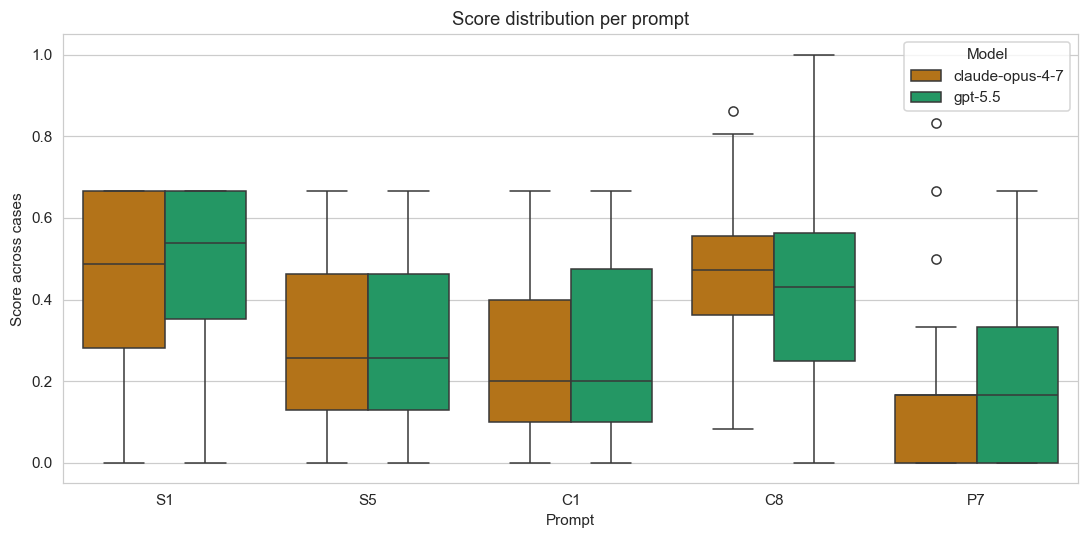

/var/folders/_d/v1hr7s_j5z3d0rl0d11r_s9w0000gn/T/ipykernel_11953/1271190988.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  variance = done.groupby(["prompt_id", "mut_model"])["score_mean"].agg(["mean", "std", "count"]).round(3)


**Mean / std / n per prompt × Model Under Testing:**

mean    std  count
prompt_id mut_model                           
S1        claude-opus-4-7  0.437  0.235    116
          gpt-5.5          0.466  0.215    116
S5        claude-opus-4-7  0.292  0.230    116
          gpt-5.5          0.316  0.222    116
C1        claude-opus-4-7  0.260  0.196    116
          gpt-5.5          0.279  0.210    116
C8        claude-opus-4-7  0.454  0.159    144
          gpt-5.5          0.422  0.265    144
P7        claude-opus-4-7  0.165  0.159     77
          gpt-5.5          0.190  0.171     78

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
prompt_order = ["S1", "S5", "C1", "C8", "P7"]
done["prompt_id"] = pd.Categorical(done["prompt_id"], categories=prompt_order, ordered=True)
sns.boxplot(
    data=done.sort_values("prompt_id"),
    x="prompt_id", y="score_mean", hue="mut_model",
    palette={"claude-opus-4-7": "#cc7700", "gpt-5.5": "#11aa66"}, ax=ax,
)
ax.set_xlabel("Prompt"); ax.set_ylabel("Score across cases")
ax.set_title("Score distribution per prompt"); ax.set_ylim(-0.05, 1.05)
ax.legend(title="Model")
plt.tight_layout(); plt.show()

variance = done.groupby(["prompt_id", "mut_model"])["score_mean"].agg(["mean", "std", "count"]).round(3)
display(Markdown("**Mean / std / n per prompt × Model Under Testing:**"))
display(variance)


## 7. Performance by complexity tier

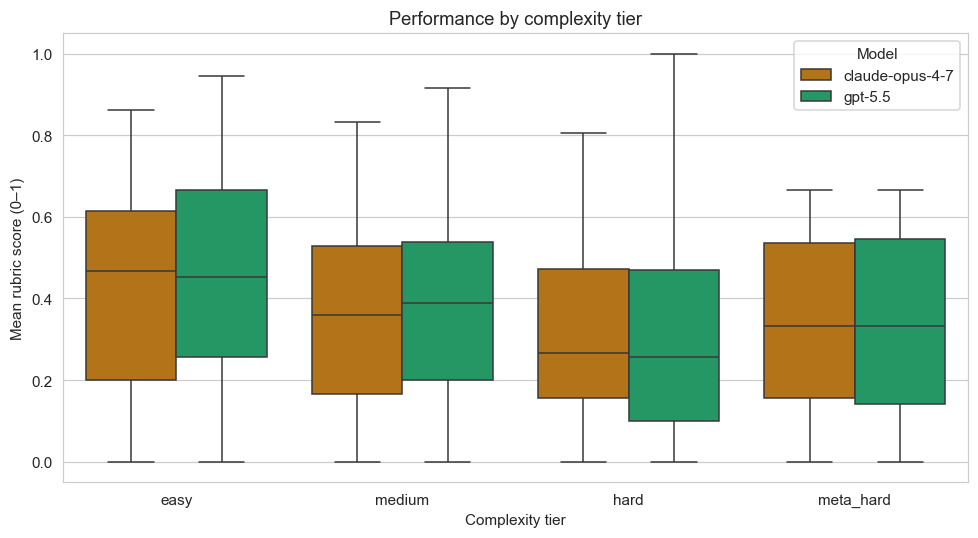

**Mean score per complexity tier × Model Under Testing:**

/var/folders/_d/v1hr7s_j5z3d0rl0d11r_s9w0000gn/T/ipykernel_11953/3457521090.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  display(done.pivot_table(index="complexity_tier", columns="mut_model",


mut_model,claude-opus-4-7,gpt-5.5
complexity_tier,,
easy,0.41,0.45
medium,0.34,0.37
hard,0.30,0.30
meta_hard,0.35,0.34


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
tier_order = ["easy", "medium", "hard", "meta_hard"]
done["complexity_tier"] = pd.Categorical(done["complexity_tier"], categories=tier_order, ordered=True)
sns.boxplot(
    data=done.sort_values("complexity_tier"),
    x="complexity_tier", y="score_mean", hue="mut_model",
    palette={"claude-opus-4-7": "#cc7700", "gpt-5.5": "#11aa66"}, ax=ax,
)
ax.set_xlabel("Complexity tier"); ax.set_ylabel("Mean rubric score (0–1)")
ax.set_title("Performance by complexity tier"); ax.set_ylim(-0.05, 1.05)
ax.legend(title="Model", loc="upper right")
plt.tight_layout(); plt.show()
display(Markdown("**Mean score per complexity tier × Model Under Testing:**"))
display(done.pivot_table(index="complexity_tier", columns="mut_model",
                         values="score_mean", aggfunc="mean").round(2))


## 8. Performance by LOS bucket

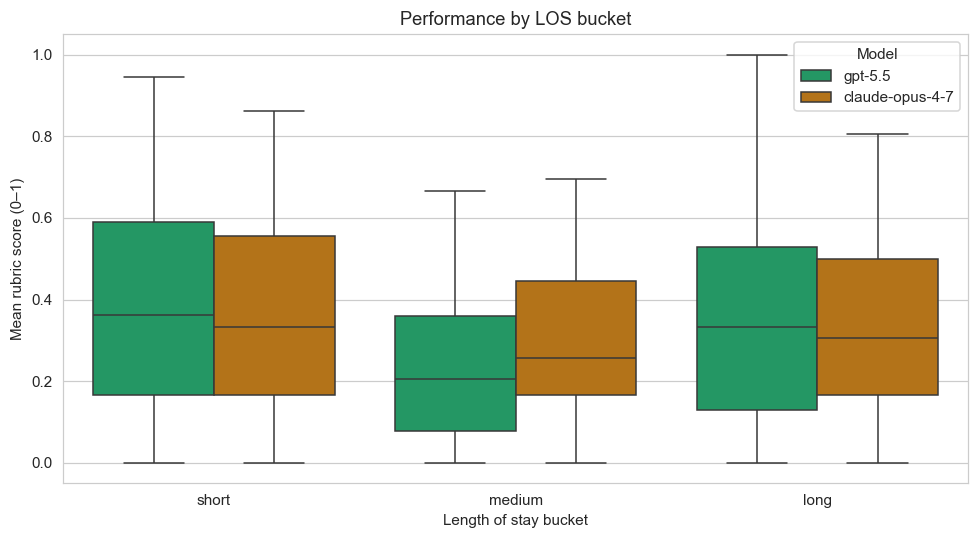

**Mean score per LOS bucket × Model Under Testing:**

/var/folders/_d/v1hr7s_j5z3d0rl0d11r_s9w0000gn/T/ipykernel_11953/4141875144.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  display(sub.pivot_table(index="los_bucket", columns="mut_model",


mut_model,claude-opus-4-7,gpt-5.5
los_bucket,,
short,0.35,0.38
medium,0.29,0.24
long,0.33,0.32


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
los_order = ["short", "medium", "long"]
sub = done[done["los_bucket"].isin(los_order)].copy()
sub["los_bucket"] = pd.Categorical(sub["los_bucket"], categories=los_order, ordered=True)
sns.boxplot(
    data=sub.sort_values("los_bucket"),
    x="los_bucket", y="score_mean", hue="mut_model",
    palette={"claude-opus-4-7": "#cc7700", "gpt-5.5": "#11aa66"}, ax=ax,
)
ax.set_xlabel("Length of stay bucket"); ax.set_ylabel("Mean rubric score (0–1)")
ax.set_title("Performance by LOS bucket"); ax.set_ylim(-0.05, 1.05)
ax.legend(title="Model", loc="upper right")
plt.tight_layout(); plt.show()
display(Markdown("**Mean score per LOS bucket × Model Under Testing:**"))
display(sub.pivot_table(index="los_bucket", columns="mut_model",
                        values="score_mean", aggfunc="mean").round(2))
